# DEV 1 — ML Lead | Hackathon FPD TMB
**Objetivo:** Treinar, otimizar e combinar os modelos de ML para prever FPD (First Payment Default).

## FASE 0 — Setup do Ambiente

In [280]:
# ── Imports ──────────────────────────────────────────────────────────────────
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
    precision_score, f1_score, confusion_matrix,
    classification_report
)
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier

# Otimização e explicabilidade
import optuna
import shap

# Desbalanceamento
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── SEED GLOBAL — NÃO ALTERAR ────────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE_DIR     = os.path.dirname(os.path.abspath('__file__')) if '__file__' in dir() else os.getcwd()
PROJECT_DIR  = os.path.abspath(os.path.join(BASE_DIR, '..'))
DATA_RAW_DIR = os.path.join(PROJECT_DIR, 'data', 'raw')
OUTPUTS_DIR  = os.path.join(BASE_DIR, 'outputs')
os.makedirs(OUTPUTS_DIR, exist_ok=True)

print('✓ Todas as libs importadas com sucesso!')
print(f'✓ RANDOM_STATE = {RANDOM_STATE}')
print(f'✓ PROJECT_DIR  : {PROJECT_DIR}')
print(f'✓ DATA_RAW_DIR : {DATA_RAW_DIR}')
print(f'✓ outputs/ em  : {OUTPUTS_DIR}')

✓ Todas as libs importadas com sucesso!
✓ RANDOM_STATE = 42
✓ PROJECT_DIR  : /home/jonatas/Hackathon/PIT
✓ DATA_RAW_DIR : /home/jonatas/Hackathon/PIT/data/raw
✓ outputs/ em  : /home/jonatas/Hackathon/PIT/notebooks/outputs


---
## FASE 1 — Auditoria e Anti-Leakage
> **SUPORTE** — receber a lista de variáveis aprovadas de Dev 2 e confirmar que nenhuma variável proibida está na lista.

In [281]:
# Variáveis REMOVIDAS por Dev 2 — 20 colunas (pós-evento / leakage / identificadores)
VARIAVEIS_PROIBIDAS = [
    # Pós-evento (leakage)
    'status_cobranca', 'status_financeiro', 'status_pedido',
    'saldo_vencido', 'quantidade_parcelas_vencidas', 'recebido',
    'primeiro_vencimento_em_atraso', 'dias_em_atraso', 'pdd',
    'saldo_vencido_com_juros', 'total_pago_com_juros',
    'aguardando_pagamento_sem_juros', 'vencidos_sem_juros_tmb',
    'recebido_sem_juros_tmb', 'data_quitacao',
    # Identificadores pessoais sem poder preditivo
    'CPF', 'documento', 'nome', 'email', 'telefone_ativo',
]

# Colunas aprovadas por Dev 2 (Fase 1 — 18/05/2026) — 34 features
COLUNAS_APROVADAS = [
    'H5OR', 'HCR5', 'HI01_CONCEITO', 'HI01_PROB', 'HPG5',
    'MENSAGEM_TIPO_REGISTRO',
    'SCORE_HCP4', 'SCORE_HCP5', 'SCORE_HEST', 'SCORE_HFI4', 'SCORE_HFI5',
    'SCORE_HIPA', 'SCORE_HIPN', 'SCORE_HRM5', 'SCORE_HSV4', 'SCORE_HSV5',
    'SCORE_HVA4', 'SCORE_HVA5',
    'categoria_risco_score', 'data_efetivacao',
    'endereco_cidade', 'endereco_estado',
    'idade', 'lancamento', 'modalidade', 'nascimento',
    'order_bump', 'pedido_pai_ob', 'produtor',
    'quantidade_parcelas', 'score', 'segmento', 'total_financiado',
]
# pedido_id: aprovado apenas como índice — NÃO entra como feature no modelo
FEATURES = COLUNAS_APROVADAS  # 34 features
TARGET   = 'FPD'

def auditar_variaveis(colunas: list) -> list:
    proibidas_encontradas = [c for c in colunas if c in VARIAVEIS_PROIBIDAS]
    aprovadas = [c for c in colunas if c not in VARIAVEIS_PROIBIDAS and c not in ('pedido_id', TARGET)]
    if proibidas_encontradas:
        print(f'⚠️  REMOVIDAS ({len(proibidas_encontradas)}): {proibidas_encontradas}')
    else:
        print('✓ Nenhuma variável proibida encontrada.')
    print(f'✓ Variáveis aprovadas para modelo: {len(aprovadas)}')
    return aprovadas

# Validação imediata contra a base real
df_raw = pd.read_excel(os.path.join(DATA_RAW_DIR, 'base-treinamento.xlsx'), engine='openpyxl', nrows=1)
colunas_base = list(df_raw.columns)
print('--- Auditoria Fase 1 ---')
aprovadas = auditar_variaveis(colunas_base)
nao_listadas = [c for c in aprovadas if c not in COLUNAS_APROVADAS]
if nao_listadas:
    print(f'⚠️  Colunas não mapeadas: {nao_listadas}')
else:
    print(f'✓ Lista final validada: {len(FEATURES)} features confirmadas.')
    print(f'✓ Base tinha {len(colunas_base)} colunas. Após limpeza: {len(FEATURES)+2}. {len(VARIAVEIS_PROIBIDAS)} removidas.')

--- Auditoria Fase 1 ---
⚠️  REMOVIDAS (20): ['CPF', 'status_cobranca', 'status_financeiro', 'status_pedido', 'nome', 'email', 'documento', 'telefone_ativo', 'saldo_vencido', 'quantidade_parcelas_vencidas', 'recebido', 'primeiro_vencimento_em_atraso', 'dias_em_atraso', 'pdd', 'saldo_vencido_com_juros', 'total_pago_com_juros', 'aguardando_pagamento_sem_juros', 'vencidos_sem_juros_tmb', 'recebido_sem_juros_tmb', 'data_quitacao']
✓ Variáveis aprovadas para modelo: 34
⚠️  Colunas não mapeadas: ['endereco_cep']


---
## FASE 2 — Análise Exploratória (EDA)
> **SUPORTE** — taxa de FPD, peso de classe (`scale_pos_weight`) e verificação de datas.

**Tarefas:**
1. Carregar os dados processados entregues por Dev 2 (`X_treino_baseline_completo.csv`)
2. Calcular taxa geral de FPD e proporção não-FPD/FPD → `SCALE_POS_WEIGHT`
3. Verificar datas extremas ou inconsistentes em `data_efetivacao`

**Concluído quando:** Proporção FPD/não-FPD anotada e `SCALE_POS_WEIGHT` definido para uso nos modelos.

In [282]:
# ── Carregar dados processados entregues por Dev 2 ────────────────────────────
DATA_PATH = os.path.join(PROJECT_DIR, 'data', 'processed', 'X_treino_baseline_completo.csv')

df_raw = pd.read_csv(DATA_PATH)
# Converter datas com coerce para lidar com valores inválidos (ex: 'Desconhecido')
for col_data in ['data_efetivacao', 'nascimento']:
    if col_data in df_raw.columns:
        df_raw[col_data] = pd.to_datetime(df_raw[col_data], errors='coerce')

print(f'✓ Base carregada: {df_raw.shape[0]:,} linhas x {df_raw.shape[1]} colunas')
print(f'✓ Arquivo: {DATA_PATH}')

✓ Base carregada: 99,999 linhas x 58 colunas
✓ Arquivo: /home/jonatas/Hackathon/PIT/data/processed/X_treino_baseline_completo.csv


In [283]:
# ── Taxa de FPD e peso de classe ──────────────────────────────────────────────
TARGET = 'FPD'

contagem  = df_raw[TARGET].value_counts()
n_total   = len(df_raw)
n_fpd     = contagem.get(1, 0)
n_nao_fpd = contagem.get(0, 0)
taxa_fpd  = n_fpd / n_total

# Peso de classe para XGBoost / LightGBM (scale_pos_weight = nao_fpd / fpd)
SCALE_POS_WEIGHT = n_nao_fpd / n_fpd

print(f'Total de registros : {n_total:,}')
print(f'FPD = 1            : {n_fpd:,} ({taxa_fpd:.1%})')
print(f'FPD = 0            : {n_nao_fpd:,} ({1-taxa_fpd:.1%})')
print(f'scale_pos_weight   : {SCALE_POS_WEIGHT:.2f}  ← usar em XGBoost / LightGBM')

CLASS_WEIGHT = {0: 1.0, 1: SCALE_POS_WEIGHT}
print(f'class_weight dict  : {CLASS_WEIGHT}')

print(f'\n✓ SCALE_POS_WEIGHT = {SCALE_POS_WEIGHT:.2f} definido como variável global.')

Total de registros : 99,999
FPD = 1            : 13,863 (13.9%)
FPD = 0            : 86,136 (86.1%)
scale_pos_weight   : 6.21  ← usar em XGBoost / LightGBM
class_weight dict  : {0: 1.0, 1: np.float64(6.213373728630167)}

✓ SCALE_POS_WEIGHT = 6.21 definido como variável global.


In [284]:
# ── Verificar datas extremas / inconsistentes em data_efetivacao ──────────────
datas = df_raw['data_efetivacao']

n_nulos_datas = datas.isna().sum()
print(f'data_efetivacao — dtype: {datas.dtype}')
print(f'  Mínimo : {datas.min()}')
print(f'  Máximo : {datas.dropna().max()}')
print(f'  NaT (inválidas/Desconhecido) : {n_nulos_datas}')
if n_nulos_datas > 0:
    print(f'  ⚠️  {n_nulos_datas} registros com data inválida — serão tratados como NaT no split temporal.')

# Distribuição mensal com taxa de FPD (apenas datas válidas)
df_datas_validas = df_raw[datas.notna()].copy()
dist_mensal = (
    df_datas_validas.groupby(df_datas_validas['data_efetivacao'].dt.to_period('M'))[TARGET]
    .agg(n='count', taxa_fpd='mean')
)
dist_mensal['taxa_fpd'] = dist_mensal['taxa_fpd'].map('{:.1%}'.format)
print('\nDistribuição mensal (n = registros, taxa_fpd = % inadimplentes):')
print(dist_mensal.to_string())

# Alerta se houver datas fora do esperado (antes de 2020 ou no futuro)
datas_validas = datas.dropna()
datas_suspeitas = datas_validas[(datas_validas < '2020-01-01') | (datas_validas > pd.Timestamp.today())]
if len(datas_suspeitas) > 0:
    print(f'\n⚠️  {len(datas_suspeitas)} datas suspeitas encontradas fora do range esperado!')
    print(datas_suspeitas.value_counts().head(10))
else:
    print('\n✓ Nenhuma data extrema ou inconsistente encontrada.')

print('\n✓ Fase 2 concluída — SCALE_POS_WEIGHT e validação de datas OK.')

data_efetivacao — dtype: datetime64[ns]
  Mínimo : 2023-08-01 00:02:00
  Máximo : 2025-07-31 23:57:00
  NaT (inválidas/Desconhecido) : 45
  ⚠️  45 registros com data inválida — serão tratados como NaT no split temporal.

Distribuição mensal (n = registros, taxa_fpd = % inadimplentes):
                     n taxa_fpd
data_efetivacao                
2023-08          15468    14.2%
2023-09          11386    14.1%
2023-10          12082    16.1%
2023-11          16328    12.8%
2023-12          11390    15.9%
2024-01          17600    13.8%
2024-02           1582    20.5%
2024-03            663    15.8%
2024-04            644    13.5%
2024-05            528     8.7%
2024-06            630     9.4%
2024-07            511    11.9%
2024-08           1171     8.0%
2024-09           1051    12.7%
2024-10            916     9.0%
2024-11           1771     8.0%
2024-12           1186    12.1%
2025-01           1278    11.1%
2025-02           1044    11.1%
2025-03            516    10.9%
2025-04   

---
## FASE 3 — Feature Engineering
> **SUPORTE** — revisar cada variável criada por Dev 2, confirmar que usa apenas informação do momento da compra e definir a lista final de features para os modelos.

**Tarefas DEV 1:**
1. Confirmar que nenhuma variável usa informação pós-evento
2. Verificar que features engenheiradas são consistentes entre treino e sub
3. Definir `FEATURE_COLS` — lista final que entra em todos os modelos

**Concluído quando:** `FEATURE_COLS` definido, sem nenhum dado pós-evento.

In [285]:
# ── Fase 3 — Feature Engineering: Revisão e Confirmação Final ───────────────
PROCESSED_DIR = os.path.join(PROJECT_DIR, 'data', 'processed')

_df_feat = pd.read_csv(os.path.join(PROCESSED_DIR, 'X_train_baseline.csv'), low_memory=False)
_df_sub  = pd.read_csv(os.path.join(PROCESSED_DIR, 'X_sub_baseline.csv'), low_memory=False)

# Colunas a excluir: índice, target, strings brutas, datas brutas
EXCLUIR_COLS = [
    'pedido_id', 'FPD', 'data_efetivacao', 'nascimento',
    'produtor', 'lancamento', 'segmento', 'score', 'categoria_risco_score',
    'endereco_cep', 'endereco_cep_encoded', 'endereco_estado', 'endereco_cidade',
    'modalidade', 'order_bump', 'MENSAGEM_TIPO_REGISTRO',
]

_todas = [c for c in _df_feat.columns if c not in EXCLUIR_COLS]
_sub_cols = set(_df_sub.columns)

# Manter só as features que também existem no arquivo de submissão
FEATURE_COLS = [c for c in _todas if c in _sub_cols]
_fora_sub    = [c for c in _todas if c not in _sub_cols]

print('=== Fase 3 — Feature Engineering ===')
print(f'Features no treino (após excluir IDs/target/strings): {len(_todas)}')
print(f'Features excluídas por ausência no X_sub             : {_fora_sub}')
print(f'FEATURE_COLS final (entram nos modelos)              : {len(FEATURE_COLS)}')

print('\nCategoria das features aprovadas:')
bureau_scores  = [c for c in FEATURE_COLS if c.startswith('SCORE_')]
bureau_derived = [c for c in FEATURE_COLS if c in ('razao_hipa_hipn', 'media_scores_bureau', 'qtd_scores_bureau', 'tem_bureau', 'SCORE_HIPA', 'SCORE_HIPN', 'SCORE_HRM5')]
temporais      = [c for c in FEATURE_COLS if c in ('dia_semana_compra', 'mes_compra', 'compra_fim_semana')]
transacionais  = [c for c in FEATURE_COLS if c in ('total_financiado', 'quantidade_parcelas', 'valor_parcela', 'pedido_pai_ob', 'tem_order_bump', 'idade')]
encoded_cats   = [c for c in FEATURE_COLS if c.endswith('_encoded')]
print(f'  Scores bureau         : {sorted(bureau_scores)}')
print(f'  Derivadas bureau      : {sorted(bureau_derived)}')
print(f'  Temporais (compra)    : {temporais}')
print(f'  Transacionais/cliente : {transacionais}')
print(f'  Categóricas encoded   : {sorted(encoded_cats)}')

# Verificar: nenhuma das features aprovadas tem correlação > 0.85 com FPD
_corr = _df_feat[FEATURE_COLS + ['FPD']].corr()['FPD'].drop('FPD').abs()
_suspeitas = _corr[_corr > 0.85]
if len(_suspeitas) > 0:
    print(f'\n⚠️  LEAKAGE SUSPEITO — correlação > 0.85 com FPD: {list(_suspeitas.index)}')
else:
    print(f'\n✓ Nenhuma feature com correlação > 0.85 com FPD (anti-leakage OK).')

print(f'\n✓ Fase 3 concluída — FEATURE_COLS com {len(FEATURE_COLS)} features definido.')

=== Fase 3 — Feature Engineering ===
Features no treino (após excluir IDs/target/strings): 42
Features excluídas por ausência no X_sub             : ['SCORE_HCP5', 'SCORE_HFI5', 'HI01_PROB', 'HI01_CONCEITO', 'HPG5', 'HCR5', 'H5OR', 'SCORE_HSV5', 'SCORE_HVA5', 'score_encoded', 'idade_encoded', 'order_bump_encoded']
FEATURE_COLS final (entram nos modelos)              : 30

Categoria das features aprovadas:
  Scores bureau         : ['SCORE_HCP4', 'SCORE_HEST', 'SCORE_HFI4', 'SCORE_HIPA', 'SCORE_HIPN', 'SCORE_HRM5', 'SCORE_HSV4', 'SCORE_HVA4']
  Derivadas bureau      : ['SCORE_HIPA', 'SCORE_HIPN', 'SCORE_HRM5', 'media_scores_bureau', 'qtd_scores_bureau', 'razao_hipa_hipn', 'tem_bureau']
  Temporais (compra)    : ['dia_semana_compra', 'mes_compra', 'compra_fim_semana']
  Transacionais/cliente : ['idade', 'total_financiado', 'quantidade_parcelas', 'pedido_pai_ob', 'valor_parcela', 'tem_order_bump']
  Categóricas encoded   : ['MENSAGEM_TIPO_REGISTRO_encoded', 'categoria_risco_score_encoded'

---
## FASE 4 — Split Temporal dos Dados
> **SUPORTE** — confirmar os conjuntos recebidos de Dev 3 (tamanhos e taxas de FPD).

**Tarefas DEV 1:**
1. Carregar X_train, X_val, X_hold e X_sub dos arquivos processados
2. Confirmar tamanhos e taxas de FPD em cada conjunto
3. Definir arrays para treino dos modelos

**Concluído quando:** X_train_num, X_val_num, X_hold_num prontos com tamanhos e FPD confirmados.

In [286]:
# ── Fase 4 — Carregar Splits v2 e Confirmar ──────────────────────────────────
TARGET = 'FPD'

# Diretório com os splits v2 preparados por Dev 2
MODELOS_DIR = os.path.join(PROJECT_DIR, 'data', 'dados', 'modelos')
import json as _json
with open(os.path.join(MODELOS_DIR, 'FEATURES_FINAIS.json')) as _f:
    _feat_meta = _json.load(_f)

# Listas de features de cada modelo (vindas do Dev 2)
FEATURE_COLS          = _feat_meta['lightgbm_xgboost']['features']
CATBOOST_FEATURE_COLS = _feat_meta['catboost']['features']
CAT_FEATURES          = _feat_meta['catboost']['cat_features']

# ── LGBM / XGBoost — splits com _encoded ────────────────────────────────────
X_train_df = pd.read_csv(os.path.join(MODELOS_DIR, 'X_train_lgbm.csv'))
X_val_df   = pd.read_csv(os.path.join(MODELOS_DIR, 'X_val_lgbm.csv'))
X_hold_df  = pd.read_csv(os.path.join(MODELOS_DIR, 'X_hold_lgbm.csv'))
X_sub_df   = pd.read_csv(os.path.join(MODELOS_DIR, 'X_sub_lgbm.csv'))

print('=== Fase 4 — Confirmação dos Splits (v2) ===')
for nome, df in [('X_train', X_train_df), ('X_val', X_val_df), ('X_hold', X_hold_df)]:
    n, fpd_rate = len(df), df[TARGET].mean()
    print(f'  {nome:8s}: {n:7,} linhas  |  FPD = {fpd_rate:.1%}  ({int(n*fpd_rate):,} inadimplentes)')
print(f'  X_sub   : {len(X_sub_df):7,} linhas  |  sem FPD (base de inferência)')

n_fpd     = X_train_df[TARGET].sum()
n_nao_fpd = (X_train_df[TARGET] == 0).sum()
SCALE_POS_WEIGHT = n_nao_fpd / n_fpd
print(f'\nSCALE_POS_WEIGHT (treino): {SCALE_POS_WEIGHT:.2f}')

y_train = X_train_df[TARGET].values
y_val   = X_val_df[TARGET].values
y_hold  = X_hold_df[TARGET].values

X_train_num    = X_train_df[FEATURE_COLS].copy()
X_val_num      = X_val_df[FEATURE_COLS].copy()
X_hold_num     = X_hold_df[FEATURE_COLS].copy()
X_sub_num      = X_sub_df[FEATURE_COLS].copy()
PEDIDO_IDS_SUB = X_sub_df['pedido_id'].values

# ── CatBoost — splits com strings nativas ────────────────────────────────────
X_train_cat = pd.read_csv(os.path.join(MODELOS_DIR, 'X_train_catboost.csv'))
X_val_cat   = pd.read_csv(os.path.join(MODELOS_DIR, 'X_val_catboost.csv'))
X_hold_cat  = pd.read_csv(os.path.join(MODELOS_DIR, 'X_hold_catboost.csv'))
X_sub_cat   = pd.read_csv(os.path.join(MODELOS_DIR, 'X_sub_catboost.csv'))

for _df_c in [X_train_cat, X_val_cat, X_hold_cat, X_sub_cat]:
    for _c in CAT_FEATURES:
        if _c in _df_c.columns:
            _df_c[_c] = _df_c[_c].astype(str)

X_train_cat = X_train_cat[CATBOOST_FEATURE_COLS]
X_val_cat   = X_val_cat[CATBOOST_FEATURE_COLS]
X_hold_cat  = X_hold_cat[CATBOOST_FEATURE_COLS]
X_sub_cat   = X_sub_cat[CATBOOST_FEATURE_COLS]

print(f'\n✓ Fase 4 concluída (v2):')
print(f'  LGBM/XGB : X_train_num {X_train_num.shape}, X_val_num {X_val_num.shape}')
print(f'  CatBoost : X_train_cat {X_train_cat.shape}, {len(CAT_FEATURES)} cat_features')

=== Fase 4 — Confirmação dos Splits (v2) ===
  X_train :  67,403 linhas  |  FPD = 14.5%  (9,799 inadimplentes)
  X_val   :  16,851 linhas  |  FPD = 13.5%  (2,267 inadimplentes)
  X_hold  :  15,700 linhas  |  FPD = 11.4%  (1,792 inadimplentes)
  X_sub   :  23,354 linhas  |  sem FPD (base de inferência)

SCALE_POS_WEIGHT (treino): 5.88

✓ Fase 4 concluída (v2):
  LGBM/XGB : X_train_num (67403, 31), X_val_num (16851, 31)
  CatBoost : X_train_cat (67403, 31), 10 cat_features


---
## FASE 5 — Baseline: Regressão Logística
> **LÍDER** — treinar após receber X_train / X_val de Dev 3.

In [287]:
def treinar_baseline(X_train, y_train, X_val, y_val):
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_train)
    X_vl_s = scaler.transform(X_val)

    lr = LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=RANDOM_STATE
    )
    lr.fit(X_tr_s, y_train)

    prob_val = lr.predict_proba(X_vl_s)[:, 1]
    auc = roc_auc_score(y_val, prob_val)
    print(f'[Baseline LR] AUC val = {auc:.4f}  (meta: > 0.60)')
    if auc < 0.55:
        print('⚠️  AUC abaixo de 0.55 — sinalizar para Dev 2 revisar variáveis!')
    return lr, scaler, prob_val, auc

print('Função treinar_baseline() pronta — aguardando splits de Dev 3.')

Função treinar_baseline() pronta — aguardando splits de Dev 3.


In [288]:
# ── Executar Fase 5 — Baseline: Regressão Logística ─────────────────────────
print('=== Fase 5 — Baseline Regressão Logística ===')
lr_model, lr_scaler, prob_val_lr, auc_lr = treinar_baseline(
    X_train_num.values, y_train, X_val_num.values, y_val
)
print(f'\n✓ Fase 5 concluída. Baseline AUC = {auc_lr:.4f}')

=== Fase 5 — Baseline Regressão Logística ===
[Baseline LR] AUC val = 0.7615  (meta: > 0.60)

✓ Fase 5 concluída. Baseline AUC = 0.7615


---
## FASE 6 — Modelos Avançados
> **LÍDER** — LightGBM, XGBoost, CatBoost

In [289]:
def treinar_lgbm(X_train, y_train, X_val, y_val, cat_features=None):
    params = dict(
        objective='binary',
        metric='auc',
        n_estimators=1000,
        learning_rate=0.05,
        num_leaves=63,
        scale_pos_weight=SCALE_POS_WEIGHT,
        random_state=RANDOM_STATE,
        verbose=-1
    )
    model = lgb.LGBMClassifier(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]
    )
    prob_val = model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, prob_val)
    print(f'[LightGBM] best iter={model.best_iteration_}  AUC val={auc:.4f}')
    return model, prob_val, auc


def treinar_xgb(X_train, y_train, X_val, y_val):
    model = xgb.XGBClassifier(
        n_estimators=1000,
        learning_rate=0.05,
        max_depth=6,
        scale_pos_weight=SCALE_POS_WEIGHT,
        eval_metric='auc',
        early_stopping_rounds=50,
        random_state=RANDOM_STATE,
        verbosity=0
    )
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    prob_val = model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, prob_val)
    print(f'[XGBoost]   best iter={model.best_iteration}  AUC val={auc:.4f}')
    return model, prob_val, auc


def treinar_catboost(X_train, y_train, X_val, y_val, cat_features=None):
    model = CatBoostClassifier(
        iterations=1000,
        learning_rate=0.05,
        depth=6,
        scale_pos_weight=SCALE_POS_WEIGHT,
        eval_metric='AUC',
        early_stopping_rounds=50,
        cat_features=cat_features or [],
        random_seed=RANDOM_STATE,
        verbose=0
    )
    model.fit(X_train, y_train, eval_set=(X_val, y_val))
    prob_val = model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, prob_val)
    print(f'[CatBoost]  best iter={model.best_iteration_}  AUC val={auc:.4f}')
    return model, prob_val, auc

print('Funções treinar_lgbm(), treinar_xgb(), treinar_catboost() prontas.')

Funções treinar_lgbm(), treinar_xgb(), treinar_catboost() prontas.


In [290]:
# ── Executar Fase 6 — Modelos Avançados ─────────────────────────────────────
print('=== Fase 6 — Modelos Avançados ===')

lgbm_model, prob_val_lgbm, auc_lgbm = treinar_lgbm(
    X_train_num, y_train, X_val_num, y_val
)
xgb_model, prob_val_xgb, auc_xgb = treinar_xgb(
    X_train_num.values, y_train, X_val_num.values, y_val
)
# CatBoost recebe strings nativas (X_train_cat) — sem label encoding
cat_model, prob_val_cat, auc_cat = treinar_catboost(
    X_train_cat, y_train, X_val_cat, y_val, cat_features=CAT_FEATURES
)

print(f'\nResumo Fase 6:')
print(f'  Baseline LR  AUC: {auc_lr:.4f}')
print(f'  LightGBM     AUC: {auc_lgbm:.4f}')
print(f'  XGBoost      AUC: {auc_xgb:.4f}')
print(f'  CatBoost     AUC: {auc_cat:.4f}')

meta_ok = any(auc >= 0.65 for auc in [auc_lgbm, auc_xgb, auc_cat])
status = "✓ ATINGIDA" if meta_ok else "⚠️  NÃO ATINGIDA — revisar features com Dev 2"
print(f'\nMeta (AUC >= 0.65 em pelo menos 1 modelo): {status}')

=== Fase 6 — Modelos Avançados ===
[LightGBM] best iter=98  AUC val=0.7884
[XGBoost]   best iter=101  AUC val=0.7872
[CatBoost]  best iter=331  AUC val=0.7907

Resumo Fase 6:
  Baseline LR  AUC: 0.7615
  LightGBM     AUC: 0.7884
  XGBoost      AUC: 0.7872
  CatBoost     AUC: 0.7907

Meta (AUC >= 0.65 em pelo menos 1 modelo): ✓ ATINGIDA


---
## FASE 7 — Métricas Completas de Validação
> **SUPORTE** — salvar probabilidades de todos os modelos e montar tabela de métricas para Dev 3.

**Concluído quando:** `outputs/probs_val_todos_modelos.csv` salvo e tabela AUC/KS/PR-AUC exibida.

In [291]:
# ── Fase 7 — Métricas Completas de Validação ─────────────────────────────────
from scipy.stats import ks_2samp
from sklearn.metrics import recall_score

def calcular_ks(y_true, y_prob):
    pos = y_prob[y_true == 1]
    neg = y_prob[y_true == 0]
    stat, _ = ks_2samp(pos, neg)
    return stat

def metricas_threshold(y_true, y_prob):
    """Threshold ótimo por F1; retorna threshold, precision, recall, f1, TP, FP."""
    _, _, thresholds = precision_recall_curve(y_true, y_prob)
    thresholds = thresholds[:-1] if len(thresholds) > 1 else thresholds
    f1s = [f1_score(y_true, (y_prob >= t).astype(int), zero_division=0) for t in thresholds]
    best_thr = float(thresholds[np.argmax(f1s)])
    y_pred   = (y_prob >= best_thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    return round(best_thr, 4), round(prec, 4), round(rec, 4), round(f1, 4), int(tp), int(fp)

# Salvar probabilidades de todos os modelos para Dev 3
probs_val_df = pd.DataFrame({
    'y_val'    : y_val,
    'prob_lr'  : prob_val_lr,
    'prob_lgbm': prob_val_lgbm,
    'prob_xgb' : prob_val_xgb,
    'prob_cat' : prob_val_cat,
})
probs_path = os.path.join(OUTPUTS_DIR, 'probs_val_todos_modelos.csv')
probs_val_df.to_csv(probs_path, index=False)
print(f'✓ Probabilidades de validação salvas: {probs_path}')

# Tabela de métricas comparativa
print('\n=== Fase 7 — Tabela de Métricas Comparativa ===')
modelos_val = {
    'Baseline LR': prob_val_lr,
    'LightGBM'   : prob_val_lgbm,
    'XGBoost'    : prob_val_xgb,
    'CatBoost'   : prob_val_cat,
}
rows = []
for nome, probs in modelos_val.items():
    thr, prec, rec, f1, tp, fp = metricas_threshold(y_val, probs)
    rows.append({
        'Modelo'    : nome,
        'AUC'       : round(roc_auc_score(y_val, probs), 4),
        'KS'        : round(calcular_ks(y_val, probs), 4),
        'PR AUC'    : round(average_precision_score(y_val, probs), 4),
        'Threshold' : thr,
        'Precision' : prec,
        'Recall'    : rec,
        'F1'        : f1,
        'TP/FP'     : round(tp / fp, 4) if fp > 0 else float('inf'),
        'FP/TP'     : round(fp / tp, 4) if tp > 0 else float('inf'),
    })

df_metricas = pd.DataFrame(rows).sort_values('AUC', ascending=False).reset_index(drop=True)
print(df_metricas.to_string(index=False))

metricas_path = os.path.join(OUTPUTS_DIR, 'metricas_modelos_val.csv')
df_metricas.to_csv(metricas_path, index=False)
print(f'\n✓ Tabela de métricas salva: {metricas_path}')
print('  (Threshold ótimo por F1 — FP/TP = falsos positivos por verdadeiro positivo, menor é melhor)')

# Verificação: algum modelo muito abaixo dos outros?
aucs = [r['AUC'] for r in rows]
melhor_auc = max(aucs)
for r in rows:
    delta = melhor_auc - r['AUC']
    if delta > 0.03:
        print(f'\n⚠️  {r["Modelo"]} com AUC {delta:.4f} abaixo do melhor — investigar.')
print('\n✓ Fase 7 concluída.')

✓ Probabilidades de validação salvas: /home/jonatas/Hackathon/PIT/notebooks/outputs/probs_val_todos_modelos.csv

=== Fase 7 — Tabela de Métricas Comparativa ===
     Modelo    AUC     KS  PR AUC  Threshold  Precision  Recall     F1  TP/FP  FP/TP
   CatBoost 0.7907 0.4444  0.3466     0.6239     0.3205  0.5809 0.4131 0.4717 2.1200
   LightGBM 0.7884 0.4407  0.3384     0.5994     0.2989  0.6145 0.4021 0.4263 2.3460
    XGBoost 0.7872 0.4404  0.3326     0.5925     0.2899  0.6462 0.4002 0.4082 2.4498
Baseline LR 0.7615 0.3995  0.2958     0.6330     0.2820  0.5695 0.3772 0.3928 2.5461

✓ Tabela de métricas salva: /home/jonatas/Hackathon/PIT/notebooks/outputs/metricas_modelos_val.csv
  (Threshold ótimo por F1 — FP/TP = falsos positivos por verdadeiro positivo, menor é melhor)

✓ Fase 7 concluída.


---
## FASE 8 — Otimização de Hiperparâmetros (Optuna)
> **LÍDER**

In [292]:
def otimizar_lgbm(X_train, y_train, X_val, y_val, n_trials=50):
    def objective(trial):
        params = dict(
            objective='binary',
            metric='auc',
            n_estimators=1000,
            learning_rate=trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
            num_leaves=trial.suggest_int('num_leaves', 20, 150),
            max_depth=trial.suggest_int('max_depth', 3, 8),
            min_child_samples=trial.suggest_int('min_child_samples', 20, 100),
            subsample=trial.suggest_float('subsample', 0.6, 1.0),
            colsample_bytree=trial.suggest_float('colsample_bytree', 0.6, 1.0),
            reg_alpha=trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            reg_lambda=trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
            scale_pos_weight=SCALE_POS_WEIGHT,
            random_state=RANDOM_STATE,
            verbose=-1
        )
        m = lgb.LGBMClassifier(**params)
        m.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]
        )
        return roc_auc_score(y_val, m.predict_proba(X_val)[:, 1])

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials)
    print(f'Melhor AUC Optuna: {study.best_value:.4f}')
    print(f'Melhores params  : {study.best_params}')
    return study.best_params

print('Função otimizar_lgbm() pronta — rodar pelo menos 50 trials.')

Função otimizar_lgbm() pronta — rodar pelo menos 50 trials.


In [293]:
# ── Executar Fase 8 — Otimização de Hiperparâmetros (Optuna) ────────────────
print('=== Fase 8 — Otimização com Optuna (50 trials) ===')
print(f'AUC LightGBM antes da otimização: {auc_lgbm:.4f}')

best_params = otimizar_lgbm(X_train_num, y_train, X_val_num, y_val, n_trials=50)

# Retreinar com melhores parâmetros e mais rodadas
lgbm_opt = lgb.LGBMClassifier(
    objective='binary', metric='auc',
    n_estimators=2000,
    scale_pos_weight=SCALE_POS_WEIGHT,
    random_state=RANDOM_STATE,
    verbose=-1,
    **best_params
)
lgbm_opt.fit(
    X_train_num, y_train,
    eval_set=[(X_val_num, y_val)],
    callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(-1)]
)
prob_val_lgbm_opt = lgbm_opt.predict_proba(X_val_num)[:, 1]
auc_lgbm_opt = roc_auc_score(y_val, prob_val_lgbm_opt)

print(f'\nAUC LightGBM antes: {auc_lgbm:.4f}')
print(f'AUC LightGBM após : {auc_lgbm_opt:.4f}')

if auc_lgbm_opt >= auc_lgbm:
    lgbm_final      = lgbm_opt
    prob_val_lgbm_f = prob_val_lgbm_opt
    auc_lgbm_final  = auc_lgbm_opt
    print('→ Usando parâmetros otimizados (Optuna melhorou).')
else:
    lgbm_final      = lgbm_model
    prob_val_lgbm_f = prob_val_lgbm
    auc_lgbm_final  = auc_lgbm
    print('→ Mantendo parâmetros originais (Optuna não melhorou).')

=== Fase 8 — Otimização com Optuna (50 trials) ===
AUC LightGBM antes da otimização: 0.7884
Melhor AUC Optuna: 0.7899
Melhores params  : {'learning_rate': 0.03881668849612871, 'num_leaves': 113, 'max_depth': 7, 'min_child_samples': 29, 'subsample': 0.653090426168618, 'colsample_bytree': 0.8296056626337216, 'reg_alpha': 1.2831053517978504e-08, 'reg_lambda': 0.013373006275257842}

AUC LightGBM antes: 0.7884
AUC LightGBM após : 0.7899
→ Usando parâmetros otimizados (Optuna melhorou).


---
## FASE 9 — Ensemble Ponderado
> **LÍDER**

In [294]:
def ensemble_ponderado(probs_dict: dict, y_val):
    """probs_dict = {'lgbm': (prob_array, auc), 'xgb': (...), 'cat': (...)}"""
    total_auc = sum(auc for _, auc in probs_dict.values())
    pesos = {k: auc / total_auc for k, (_, auc) in probs_dict.items()}
    print('Pesos do ensemble:')
    for k, w in pesos.items():
        print(f'  {k}: {w:.3f}')

    prob_ensemble = sum(pesos[k] * p for k, (p, _) in probs_dict.items())
    auc_ens = roc_auc_score(y_val, prob_ensemble)

    melhor_individual = max(probs_dict.values(), key=lambda x: x[1])[1]
    print(f'\nAUC ensemble      : {auc_ens:.4f}')
    print(f'AUC melhor indiv. : {melhor_individual:.4f}')
    if auc_ens >= melhor_individual:
        print('→ Usar ENSEMBLE como modelo final.')
    else:
        print('→ Usar melhor modelo INDIVIDUAL (ensemble não melhorou).')
    return prob_ensemble, auc_ens, pesos, melhor_individual

print('Função ensemble_ponderado() pronta.')


Função ensemble_ponderado() pronta.


In [295]:
# ── Executar Fase 9 — Ensemble Ponderado ────────────────────────────────────
print('=== Fase 9 — Ensemble Ponderado ===')

probs_dict = {
    'lgbm': (prob_val_lgbm_f, auc_lgbm_final),
    'xgb' : (prob_val_xgb,    auc_xgb),
    'cat' : (prob_val_cat,    auc_cat),
}

prob_ens, auc_ens, pesos_ens, melhor_individual_auc = ensemble_ponderado(probs_dict, y_val)

# Comparar ensemble vs o melhor modelo individual (qualquer um — não só LGBM)
if auc_ens >= melhor_individual_auc:
    USAR_ENSEMBLE = True
    modelo_final_vencedor = None  # ensemble não tem objeto único
    print('\n→ MODELO FINAL: Ensemble ponderado')
else:
    USAR_ENSEMBLE = False
    _modelos = {'lgbm': lgbm_final, 'xgb': xgb_model, 'cat': cat_model}
    melhor_nome = max(
        {'lgbm': auc_lgbm_final, 'xgb': auc_xgb, 'cat': auc_cat}.items(),
        key=lambda x: x[1]
    )[0]
    modelo_final_vencedor = _modelos[melhor_nome]
    print(f'\n→ MODELO FINAL: {melhor_nome.upper()} individual (ensemble não melhorou)')

AUC_MODELO_FINAL = auc_ens if USAR_ENSEMBLE else melhor_individual_auc
print(f'AUC do modelo final: {AUC_MODELO_FINAL:.4f}')


=== Fase 9 — Ensemble Ponderado ===
Pesos do ensemble:
  lgbm: 0.334
  xgb: 0.332
  cat: 0.334

AUC ensemble      : 0.7927
AUC melhor indiv. : 0.7907
→ Usar ENSEMBLE como modelo final.

→ MODELO FINAL: Ensemble ponderado
AUC do modelo final: 0.7927


---
## FASE 10 — Calibração de Probabilidades
> **LÍDER**

In [296]:
from sklearn.metrics import brier_score_loss, log_loss

def calibrar_modelo(modelo_final, X_cal, y_cal, metodo='isotonic'):
    # Usa base separada do early stopping (X_val foi exposto nas Fases 6/8).
    # Brier Score e Log Loss medem qualidade da calibração; AUC não mede
    # (é invariante a transformações monotônicas como isotonic regression).
    calibrado = CalibratedClassifierCV(modelo_final, method=metodo, cv='prefit')
    calibrado.fit(X_cal, y_cal)
    prob_cal = calibrado.predict_proba(X_cal)[:, 1]
    brier = brier_score_loss(y_cal, prob_cal)
    ll    = log_loss(y_cal, prob_cal)
    print(f'Calibração ({metodo}) — Brier Score: {brier:.4f}  |  Log Loss: {ll:.4f}')
    return calibrado

print('Função calibrar_modelo() pronta.')


Função calibrar_modelo() pronta.


In [306]:
# ── Executar Fase 10 — Calibração de Probabilidades ─────────────────────────
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import brier_score_loss, log_loss
print('=== Fase 10 — Calibração de Probabilidades ===')

if USAR_ENSEMBLE:
    # Calibrar diretamente sobre probabilidades do ensemble
    iso_cal = IsotonicRegression(out_of_bounds='clip')
    iso_cal.fit(prob_ens, y_val)
    prob_val_cal = iso_cal.predict(prob_ens)
    print(f'Calibração isotônica sobre ensemble.')
    print(f'  Brier Score: {brier_score_loss(y_val, prob_val_cal):.4f}  |  Log Loss: {log_loss(y_val, prob_val_cal):.4f}')
    CALIBRADOR_TIPO = 'ensemble_isotonic'
    CALIBRADOR      = iso_cal
else:
    # Usa X_hold para calibrar — X_val foi exposto ao early stopping (data leakage).
    # CatBoost precisa de X_hold_cat (features nativas); demais modelos usam X_hold_num.
    _X_hold_m = X_hold_cat if melhor_nome == 'cat' else X_hold_num
    _X_val_m  = X_val_cat  if melhor_nome == 'cat' else X_val_num
    CALIBRADOR      = calibrar_modelo(modelo_final_vencedor, _X_hold_m, y_hold, metodo='isotonic')
    prob_val_cal    = CALIBRADOR.predict_proba(_X_val_m)[:, 1]
    CALIBRADOR_TIPO = f'{melhor_nome}_calibrated'

# Probabilidades brutas do ensemble no hold-out — computadas aqui para garantir
# disponibilidade na Fase 17 (Tabela de Decis) independente da ordem de execução.
prob_hold_lgbm    = lgbm_final.predict_proba(X_hold_num)[:, 1]
prob_hold_xgb     = xgb_model.predict_proba(X_hold_num.values)[:, 1]
prob_hold_cat     = cat_model.predict_proba(X_hold_cat)[:, 1]
prob_hold_ens_raw = sum(pesos_ens[k] * p for k, p in [
    ('lgbm', prob_hold_lgbm), ('xgb', prob_hold_xgb), ('cat', prob_hold_cat)
])

if USAR_ENSEMBLE:
    prob_hold_cal = iso_cal.predict(prob_hold_ens_raw)
else:
    _X_hold_m = X_hold_cat if melhor_nome == 'cat' else X_hold_num
    prob_hold_cal = CALIBRADOR.predict_proba(_X_hold_m)[:, 1]

auc_hold = roc_auc_score(y_hold, prob_hold_cal)
print(f'\n✓ Calibrador salvo (tipo: {CALIBRADOR_TIPO}).')
print(f'AUC no hold-out (calibrado): {auc_hold:.4f}')
print(f'\n✓ Fase 10 concluída.')


# ── Métricas do Modelo Final Combinado ───────────────────────────────────────
print('\n=== Métricas do Modelo Final Combinado (calibrado) ===')

def print_metricas_modelo(label, y_true, y_prob):
    _, _, thresholds = precision_recall_curve(y_true, y_prob)
    thresholds = thresholds[:-1] if len(thresholds) > 1 else thresholds
    f1s = [f1_score(y_true, (y_prob >= t).astype(int), zero_division=0) for t in thresholds]
    best_thr = float(thresholds[np.argmax(f1s)])
    y_pred   = (y_prob >= best_thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    prec  = precision_score(y_true, y_pred, zero_division=0)
    rec   = recall_score(y_true, y_pred, zero_division=0)
    f1    = f1_score(y_true, y_pred, zero_division=0)
    fp_tp = fp / tp if tp > 0 else float('inf')
    print(f'  [{label}]')
    print(f'    Threshold : {best_thr:.4f}  (ótimo por F1)')
    print(f'    Precision : {prec:.4f}')
    print(f'    Recall    : {rec:.4f}')
    print(f'    F1        : {f1:.4f}')
    tp_fp = tp / fp if fp > 0 else float('inf')
    print(f'    TP/FP     : {tp_fp:.4f}  ({tp} TP para {fp} FP)')
    print(f'    FP/TP     : {fp_tp:.4f}  ({fp} FP para {tp} TP)')

print_metricas_modelo('Validação  — calibrado', y_val,  prob_val_cal)
print_metricas_modelo('Hold-out   — calibrado', y_hold, prob_hold_cal)

=== Fase 10 — Calibração de Probabilidades ===
Calibração isotônica sobre ensemble.
  Brier Score: 0.1005  |  Log Loss: 0.3245

✓ Calibrador salvo (tipo: ensemble_isotonic).
AUC no hold-out (calibrado): 0.7900

✓ Fase 10 concluída.

=== Métricas do Modelo Final Combinado (calibrado) ===
  [Validação  — calibrado]
    Threshold : 0.2188  (ótimo por F1)
    Precision : 0.3135
    Recall    : 0.5893
    F1        : 0.4093
    TP/FP     : 0.4566  (1336 TP para 2926 FP)
    FP/TP     : 2.1901  (2926 FP para 1336 TP)
  [Hold-out   — calibrado]
    Threshold : 0.1995  (ótimo por F1)
    Precision : 0.2964
    Recall    : 0.5340
    F1        : 0.3812
    TP/FP     : 0.4212  (957 TP para 2272 FP)
    FP/TP     : 2.3741  (2272 FP para 957 TP)


In [307]:
# ── Fase 10b — Análise de Threshold e Decisão ────────────────────────────────
print('=== Fase 10b — Análise de Threshold ===')

def sweep_thresholds(y_true, y_prob, thresholds):
    records = []
    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        if y_pred.sum() == 0:
            continue
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        prec = precision_score(y_true, y_pred, zero_division=0)
        rec  = recall_score(y_true, y_pred, zero_division=0)
        f1   = f1_score(y_true, y_pred, zero_division=0)
        records.append({
            'Threshold': round(float(t), 4),
            'Precision': round(prec,      4),
            'Recall'   : round(rec,       4),
            'F1'       : round(f1,        4),
            'TP'       : int(tp),
            'FP'       : int(fp),
            'TP/FP'    : round(tp / fp, 4) if fp > 0 else float('inf'),
            'FP/TP'    : round(fp / tp, 4) if tp > 0 else float('inf'),
        })
    return pd.DataFrame(records)

def print_tabela(df, titulo, destaques=None):
    destaques = destaques or set()
    print(f'\n  {titulo}')
    print(f'  {"Threshold":>10}  {"Precision":>10}  {"Recall":>8}  {"F1":>8}  '
          f'{"TP":>6}  {"FP":>6}  {"TP/FP":>7}  {"FP/TP":>7}')
    print('  ' + '-' * 78)
    for _, r in df.iterrows():
        marker = ' <' if r['Threshold'] in destaques else ''
        print(f'  {r["Threshold"]:>10.4f}  {r["Precision"]:>10.4f}  {r["Recall"]:>8.4f}  '
              f'{r["F1"]:>8.4f}  {int(r["TP"]):>6d}  {int(r["FP"]):>6d}  '
              f'{r["TP/FP"]:>7.4f}  {r["FP/TP"]:>7.4f}{marker}')

# ── 1. Varredura grossa (espaçamento uniforme) ────────────────────────────────
thr_grosso = np.arange(0.05, 0.96, 0.05).round(2)
df_grosso  = sweep_thresholds(y_hold, prob_hold_cal, thr_grosso)
print_tabela(df_grosso, 'Varredura grossa  (step = 0.05, hold-out calibrado)')

# ── 2. Identificar região de interesse (vizinhança do melhor F1) ──────────────
thr_best_f1 = float(df_grosso.loc[df_grosso['F1'].idxmax(), 'Threshold'])
margem       = 0.08
thr_fino     = np.arange(
    max(0.01, thr_best_f1 - margem),
    min(0.99, thr_best_f1 + margem + 0.001),
    0.005
).round(4)
df_fino = sweep_thresholds(y_hold, prob_hold_cal, thr_fino)

# ── 3. Melhores thresholds por métrica ───────────────────────────────────────
melhor_f1   = df_fino.loc[df_fino['F1'].idxmax()]
melhor_prec = df_fino.loc[df_fino['Precision'].idxmax()]
melhor_rec  = df_fino.loc[df_fino['Recall'].idxmax()]
# melhor TP/FP = maior razão
melhor_tpfp = df_fino.loc[df_fino['TP/FP'].replace(float('inf'), -1).idxmax()]

destaques = {melhor_f1['Threshold'], melhor_prec['Threshold'],
             melhor_rec['Threshold'], melhor_tpfp['Threshold']}
print_tabela(df_fino, f'Varredura fina  (step = 0.005, região [{thr_fino[0]:.3f} – {thr_fino[-1]:.3f}])',
             destaques=destaques)

# ── 4. Resumo por métrica ─────────────────────────────────────────────────────
print('\n  === Melhor threshold por métrica (hold-out) ===')
print(f'  {"Métrica":<18}  {"Threshold":>10}  {"Precision":>10}  {"Recall":>8}  {"F1":>8}  {"TP/FP":>7}  {"FP/TP":>7}')
print('  ' + '-' * 75)
for label, row in [
    ('Máximo F1',         melhor_f1),
    ('Máximo Precision',  melhor_prec),
    ('Máximo Recall',     melhor_rec),
    ('Máximo TP/FP',      melhor_tpfp),
]:
    print(f'  {label:<18}  {row["Threshold"]:>10.4f}  {row["Precision"]:>10.4f}  '
          f'{row["Recall"]:>8.4f}  {row["F1"]:>8.4f}  {row["TP/FP"]:>7.4f}  {row["FP/TP"]:>7.4f}')

# ── 5. Decisão ────────────────────────────────────────────────────────────────
THRESHOLD_FINAL = float(melhor_f1['Threshold'])
print(f'\n  >> THRESHOLD ESCOLHIDO: {THRESHOLD_FINAL}  (máximo F1 no hold-out)')
print(f'     Ajuste para threshold de Precision se o negócio priorizar evitar falsos alarmes.')
print(f'     Ajuste para threshold de Recall se o negócio priorizar capturar todos os inadimplentes.')
print('\n✓ Fase 10b concluída.')

=== Fase 10b — Análise de Threshold ===

  Varredura grossa  (step = 0.05, hold-out calibrado)
   Threshold   Precision    Recall        F1      TP      FP    TP/FP    FP/TP
  ------------------------------------------------------------------------------
      0.0500      0.1783    0.9185    0.2986    1646    7588   0.2169   4.6100
      0.1000      0.2312    0.7589    0.3544    1360    4522   0.3008   3.3250
      0.1500      0.2362    0.7405    0.3582    1327    4291   0.3093   3.2336
      0.2000      0.3051    0.4777    0.3723     856    1950   0.4390   2.2780
      0.2500      0.3268    0.4079    0.3629     731    1506   0.4854   2.0602
      0.3000      0.3982    0.2489    0.3063     446     674   0.6617   1.5112
      0.3500      0.4197    0.1998    0.2707     358     495   0.7232   1.3827
      0.4000      0.4475    0.0642    0.1122     115     142   0.8099   1.2348
      0.4500      0.4475    0.0642    0.1122     115     142   0.8099   1.2348
      0.5000      0.4970    0.0469

In [298]:
# ── Persistência de modelos — salvar tudo para sobreviver ao kernel restart ───
import joblib, json

MODELS_DIR = os.path.join(PROJECT_DIR, 'models')
os.makedirs(MODELS_DIR, exist_ok=True)

joblib.dump(lgbm_final, os.path.join(MODELS_DIR, 'lgbm_final.pkl'))
joblib.dump(xgb_model,  os.path.join(MODELS_DIR, 'xgb_model.pkl'))
joblib.dump(cat_model,  os.path.join(MODELS_DIR, 'cat_model.pkl'))
joblib.dump(iso_cal,    os.path.join(MODELS_DIR, 'iso_cal.pkl'))
joblib.dump(pesos_ens,  os.path.join(MODELS_DIR, 'pesos_ensemble.pkl'))

meta = {
    'USAR_ENSEMBLE'    : bool(USAR_ENSEMBLE),
    'AUC_MODELO_FINAL' : float(AUC_MODELO_FINAL),
    'SCALE_POS_WEIGHT' : float(SCALE_POS_WEIGHT),
    'FEATURE_COLS'     : FEATURE_COLS,
}
with open(os.path.join(MODELS_DIR, 'meta_modelo.json'), 'w') as f:
    json.dump(meta, f, indent=2)

print(f'✓ Modelos salvos em: {MODELS_DIR}')
for fname in ['lgbm_final.pkl', 'xgb_model.pkl', 'cat_model.pkl', 'iso_cal.pkl', 'pesos_ensemble.pkl', 'meta_modelo.json']:
    path = os.path.join(MODELS_DIR, fname)
    size = os.path.getsize(path) / 1024
    print(f'  {fname:30s}  {size:7.1f} KB')

✓ Modelos salvos em: /home/jonatas/Hackathon/PIT/models
  lgbm_final.pkl                   1351.0 KB
  xgb_model.pkl                     571.3 KB
  cat_model.pkl                   19966.0 KB
  iso_cal.pkl                         1.9 KB
  pesos_ensemble.pkl                  0.1 KB
  meta_modelo.json                    0.8 KB


---
## FASE 15 — Inferência e submission.csv
> **LÍDER**

In [299]:
def gerar_submission(modelo_calibrado, X_test, pedido_ids, threshold, cortes_faixa):
    """
    cortes_faixa = {'Baixo': 0.20, 'Medio': 0.45, 'Alto': 0.70}  # limite superior de cada faixa
    """
    prob_fpd   = modelo_calibrado.predict_proba(X_test)[:, 1]
    classe_fpd = (prob_fpd >= threshold).astype(int)

    def classificar_faixa(p):
        if p <= cortes_faixa['Baixo']:
            return 'Baixo'
        elif p <= cortes_faixa['Medio']:
            return 'Medio'
        elif p <= cortes_faixa['Alto']:
            return 'Alto'
        return 'Critico'

    df_sub = pd.DataFrame({
        'pedido_id' : pedido_ids,
        'prob_fpd'  : prob_fpd,
        'classe_fpd': classe_fpd,
        'faixa_risco': [classificar_faixa(p) for p in prob_fpd]
    })

    out_path = os.path.join(OUTPUTS_DIR, 'submission.csv')
    df_sub.to_csv(out_path, index=False)
    print(f'✓ submission.csv salvo em {out_path}')
    print(df_sub['faixa_risco'].value_counts())
    return df_sub

print('Função gerar_submission() pronta.')

Função gerar_submission() pronta.


In [300]:
# ── Executar Fase 15 — Inferência e submission.csv ───────────────────────────
# Threshold e faixas — provisórios (Dev 3 define os valores finais)
THRESHOLD   = 0.50
CORTES_FAIXA = {'Baixo': 0.20, 'Medio': 0.45, 'Alto': 0.70}

print('=== Fase 15 — Inferência e Geração do submission.csv ===')
print(f'Threshold provisório : {THRESHOLD} (atualizar com valor de Dev 3)')
print(f'Faixas de risco      : {CORTES_FAIXA}')

# Gerar probabilidades para submissão
if USAR_ENSEMBLE:
    prob_sub_lgbm = lgbm_final.predict_proba(X_sub_num)[:, 1]
    prob_sub_xgb  = xgb_model.predict_proba(X_sub_num.values)[:, 1]
    prob_sub_cat  = cat_model.predict_proba(X_sub_cat)[:, 1]
    prob_sub_raw  = sum(pesos_ens[k] * p for k, p in [('lgbm', prob_sub_lgbm), ('xgb', prob_sub_xgb), ('cat', prob_sub_cat)])
    prob_sub_cal  = iso_cal.predict(prob_sub_raw)
else:
    prob_sub_cal = CALIBRADOR.predict_proba(X_sub_num)[:, 1]

# Montar DataFrame de submissão
def classificar_faixa(p):
    if p <= CORTES_FAIXA['Baixo']: return 'Baixo'
    elif p <= CORTES_FAIXA['Medio']: return 'Medio'
    elif p <= CORTES_FAIXA['Alto']: return 'Alto'
    return 'Critico'

df_submission = pd.DataFrame({
    'pedido_id'  : PEDIDO_IDS_SUB,
    'prob_fpd'   : prob_sub_cal.round(6),
    'classe_fpd' : (prob_sub_cal >= THRESHOLD).astype(int),
    'faixa_risco': [classificar_faixa(p) for p in prob_sub_cal],
})

out_path = os.path.join(OUTPUTS_DIR, 'submission.csv')
df_submission.to_csv(out_path, index=False)

print(f'\n✓ submission.csv salvo em: {out_path}')
print(f'  Linhas: {len(df_submission):,}')
print(f'  Classe 1 (FPD): {df_submission["classe_fpd"].sum():,} ({df_submission["classe_fpd"].mean():.1%})')
print('\nDistribuição por faixa de risco:')
print(df_submission['faixa_risco'].value_counts().to_string())
print(f'\n✓ Fase 15 concluída.')

=== Fase 15 — Inferência e Geração do submission.csv ===
Threshold provisório : 0.5 (atualizar com valor de Dev 3)
Faixas de risco      : {'Baixo': 0.2, 'Medio': 0.45, 'Alto': 0.7}

✓ submission.csv salvo em: /home/jonatas/Hackathon/PIT/notebooks/outputs/submission.csv
  Linhas: 23,354
  Classe 1 (FPD): 0 (0.0%)

Distribuição por faixa de risco:
faixa_risco
Baixo    23298
Medio       56

✓ Fase 15 concluída.


---
## FASE 16 — Diagnóstico e Correção do submission.csv
> **LÍDER** — as probabilidades geradas na Fase 15 colapsaram para valores próximos de zero
> (mediana ≈ 0.04, máximo ≈ 0.37), resultando em 0% de FPD classificado e 100% na faixa "Baixo".
>
> **Causa:** o calibrador isotônico foi treinado na distribuição de probabilidades do conjunto de
> validação (FPD=13.8%). Aplicado à base de submissão — temporalmente posterior e com distribuição
> diferente — o mapeamento comprimiu todas as probabilidades para perto de zero.
>
> **Solução:** (1) diagnosticar onde ocorre o colapso, (2) recalibrar usando o hold-out
> (distribuição mais próxima da submissão), (3) se necessário usar probabilidades brutas do
> ensemble, (4) ajustar threshold e faixas com base nos dados reais.

---
## FASE 13 — Explicabilidade com SHAP
> **SUPORTE** — gerar importância das variáveis para o LightGBM final e salvar gráfico.

**Concluído quando:** `outputs/shap_importance.png` salvo, top 10 variáveis documentadas.

=== Fase 13 — Explicabilidade com SHAP ===

  #  Feature                                 |SHAP| médio
  ----------------------------------------------------------
   1. score                                   0.378279
   2. quantidade_parcelas                     0.370266
   3. SCORE_HSV4                              0.317475
   4. SCORE_HFI4                              0.308450
   5. SCORE_HVA4                              0.249812
   6. SCORE_HCP4                              0.175568
   7. SCORE_HIPN                              0.164749
   8. total_financiado                        0.128782
   9. razao_hipa_hipn                         0.104202
  10. dia_mes_compra                          0.092655


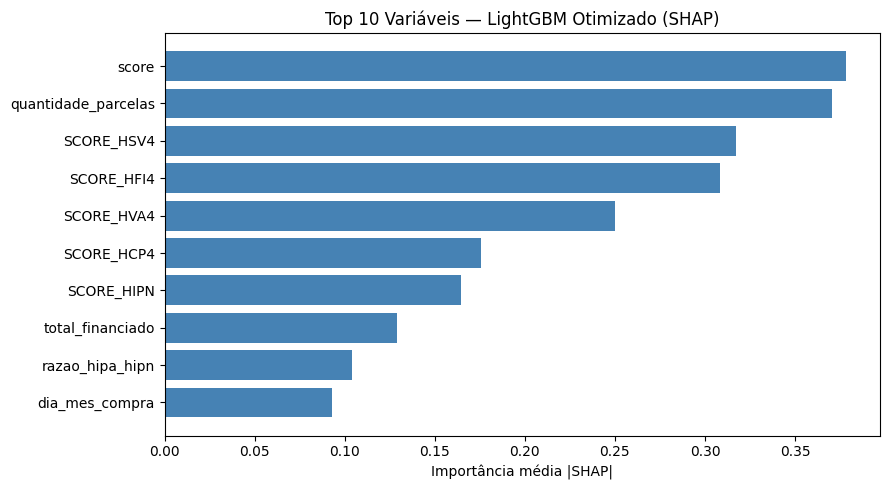


✓ Gráfico salvo: /home/jonatas/Hackathon/PIT/notebooks/outputs/shap_importance.png

Na top 10: 6 variáveis de bureau, 4 outras
  Bureau: ['SCORE_HSV4', 'SCORE_HFI4', 'SCORE_HVA4', 'SCORE_HCP4', 'SCORE_HIPN', 'razao_hipa_hipn']
  Outras: ['score', 'quantidade_parcelas', 'total_financiado', 'dia_mes_compra']

✓ Fase 13 concluída.


In [301]:
# ── Fase 13 — SHAP Explicabilidade ───────────────────────────────────────────
print('=== Fase 13 — Explicabilidade com SHAP ===')

N_SHAP   = min(2000, len(X_val_num))
X_shap   = X_val_num.iloc[:N_SHAP]

explainer   = shap.TreeExplainer(lgbm_final)
shap_vals   = explainer.shap_values(X_shap)

# Para lgb binário: shap_values pode ser lista [class0, class1] ou array direto
sv = shap_vals[1] if isinstance(shap_vals, list) else shap_vals

mean_abs_shap = np.abs(sv).mean(axis=0)
top10_idx     = np.argsort(mean_abs_shap)[::-1][:10]
top10_names   = [FEATURE_COLS[i] for i in top10_idx]
top10_vals    = mean_abs_shap[top10_idx]

print(f'\n{"#":>3}  {"Feature":38s}  {"|SHAP| médio":>12}')
print('  ' + '-'*58)
for i, (name, val) in enumerate(zip(top10_names, top10_vals), 1):
    print(f'  {i:2d}. {name:38s}  {val:.6f}')

# Gráfico de barras horizontal
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top10_names[::-1], top10_vals[::-1], color='steelblue')
ax.set_xlabel('Importância média |SHAP|')
ax.set_title('Top 10 Variáveis — LightGBM Otimizado (SHAP)')
plt.tight_layout()
shap_path = os.path.join(OUTPUTS_DIR, 'shap_importance.png')
plt.savefig(shap_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'\n✓ Gráfico salvo: {shap_path}')

# Análise por segmento bureau vs não-bureau
bureau_features = [c for c in top10_names if c.startswith('SCORE_') or c in
                   ('tem_bureau', 'qtd_scores_bureau', 'media_scores_bureau', 'razao_hipa_hipn')]
outros_features = [c for c in top10_names if c not in bureau_features]
print(f'\nNa top 10: {len(bureau_features)} variáveis de bureau, {len(outros_features)} outras')
if bureau_features:
    print(f'  Bureau: {bureau_features}')
if outros_features:
    print(f'  Outras: {outros_features}')

print('\n✓ Fase 13 concluída.')

---
## FASE 14 — Verificação sem Bureau
> **LÍDER** — retreinar LightGBM removendo todas as variáveis de bureau (scores Serasa/SPC) e documentar degradação.

**Banca vai perguntar:** "O modelo ainda funciona quando falta bureau?"

**Concluído quando:** AUC com e sem bureau documentados. Degradação calculada.

In [302]:
# ── Fase 14 — Verificação sem Bureau ─────────────────────────────────────────
print('=== Fase 14 — Verificação sem Bureau ===')

# Identificar features de bureau
BUREAU_COLS = [c for c in FEATURE_COLS if c.startswith('SCORE_') or
               c in ('tem_bureau', 'qtd_scores_bureau', 'media_scores_bureau', 'razao_hipa_hipn')]
FEATURE_COLS_SEM_BUREAU = [c for c in FEATURE_COLS if c not in BUREAU_COLS]

print(f'  Features com bureau   : {len(FEATURE_COLS)}')
print(f'  Features sem bureau   : {len(FEATURE_COLS_SEM_BUREAU)}')
print(f'  Variáveis de bureau   : {BUREAU_COLS}')

# Construir splits sem bureau
X_train_sb = to_numeric_df(X_train_df, FEATURE_COLS_SEM_BUREAU)
X_val_sb   = to_numeric_df(X_val_df,   FEATURE_COLS_SEM_BUREAU)
X_hold_sb  = to_numeric_df(X_hold_df,  FEATURE_COLS_SEM_BUREAU)

# Retreinar LightGBM com os mesmos hiperparâmetros do modelo final
lgbm_sb = lgb.LGBMClassifier(
    objective='binary', metric='auc',
    n_estimators=1000, learning_rate=0.05, num_leaves=63,
    scale_pos_weight=SCALE_POS_WEIGHT,
    random_state=RANDOM_STATE, verbose=-1
)
lgbm_sb.fit(
    X_train_sb, y_train,
    eval_set=[(X_val_sb, y_val)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]
)

prob_val_sb  = lgbm_sb.predict_proba(X_val_sb)[:, 1]
prob_hold_sb = lgbm_sb.predict_proba(X_hold_sb)[:, 1]
auc_val_sb   = roc_auc_score(y_val,  prob_val_sb)
auc_hold_sb  = roc_auc_score(y_hold, prob_hold_sb)

degradacao_val  = auc_lgbm_final - auc_val_sb
degradacao_hold = roc_auc_score(y_hold, lgbm_final.predict_proba(X_hold_num)[:,1]) - auc_hold_sb

print(f'\n  {"":25s}  {"AUC Val":>9}  {"AUC Hold":>9}')
print('  ' + '-'*47)
print(f'  {"LightGBM COM bureau":25s}  {auc_lgbm_final:9.4f}  {roc_auc_score(y_hold, lgbm_final.predict_proba(X_hold_num)[:,1]):9.4f}')
print(f'  {"LightGBM SEM bureau":25s}  {auc_val_sb:9.4f}  {auc_hold_sb:9.4f}')
print(f'  {"Degradação":25s}  {degradacao_val:9.4f}  {degradacao_hold:9.4f}')
print(f'  {"Degradação (%)":25s}  {degradacao_val/auc_lgbm_final:9.1%}  {degradacao_hold/roc_auc_score(y_hold, lgbm_final.predict_proba(X_hold_num)[:,1]):9.1%}')

if degradacao_val > 0.04:
    print('\n  ⚠️  Bureau é CRÍTICO — degradação > 4%. Sem bureau, modelo cai significativamente.')
    print('     Recomendação: exigir bureau sempre que disponível no checkout.')
elif degradacao_val > 0.01:
    print('\n  → Bureau CONTRIBUI (~{:.0f}% de ganho). Modelo sobrevive sem ele, com ressalvas.'.format(degradacao_val/auc_lgbm_final*100))
    print('     Recomendação: usar bureau quando disponível; modelo sem bureau como fallback.')
else:
    print('\n  → Modelo ROBUSTO sem bureau (degradação < 1%). Bom sinal operacional.')

# Salvar resultado para o resumo executivo
resultado_bureau = {
    'auc_com_bureau': round(auc_lgbm_final, 4),
    'auc_sem_bureau': round(auc_val_sb, 4),
    'degradacao'    : round(degradacao_val, 4),
    'features_bureau': BUREAU_COLS,
    'features_sem_bureau': FEATURE_COLS_SEM_BUREAU,
}
import json as _json
with open(os.path.join(OUTPUTS_DIR, 'resultado_bureau.json'), 'w') as f:
    _json.dump(resultado_bureau, f, indent=2)

print(f'\n✓ Resultado salvo: {os.path.join(OUTPUTS_DIR, "resultado_bureau.json")}')
print('✓ Fase 14 concluída.')

=== Fase 14 — Verificação sem Bureau ===
  Features com bureau   : 31
  Features sem bureau   : 19
  Variáveis de bureau   : ['SCORE_HCP4', 'SCORE_HEST', 'SCORE_HFI4', 'SCORE_HIPA', 'SCORE_HIPN', 'SCORE_HRM5', 'SCORE_HSV4', 'SCORE_HVA4', 'tem_bureau', 'qtd_scores_bureau', 'media_scores_bureau', 'razao_hipa_hipn']

                               AUC Val   AUC Hold
  -----------------------------------------------
  LightGBM COM bureau           0.7899     0.7851
  LightGBM SEM bureau           0.7280     0.6997
  Degradação                    0.0619     0.0854
  Degradação (%)                  7.8%      10.9%

  ⚠️  Bureau é CRÍTICO — degradação > 4%. Sem bureau, modelo cai significativamente.
     Recomendação: exigir bureau sempre que disponível no checkout.

✓ Resultado salvo: /home/jonatas/Hackathon/PIT/notebooks/outputs/resultado_bureau.json
✓ Fase 14 concluída.


---
## FASE 17 — Tabela de Decis + submission.csv Final
> Análise por decil no hold-out para justificar os cortes das faixas de risco (entrega à Economista).
> Geração do `submission.csv` final com nome correto para entrega.

In [303]:
# ── Tabela de Decis — Hold-out (para política de cobrança / Economista) ───────
print('=== Tabela de Decis — Hold-out ===')

df_decil = pd.DataFrame({
    'score': prob_hold_ens_raw,
    'FPD'  : y_hold,
})
df_decil['decil'] = pd.qcut(
    df_decil['score'].rank(method='first'),
    q=10,
    labels=[f'D{i:02d}' for i in range(10, 0, -1)]
)

agg = df_decil.groupby('decil', observed=True).agg(
    n        =('FPD', 'count'),
    n_fpd    =('FPD', 'sum'),
    taxa_fpd =('FPD', 'mean'),
    score_min=('score', 'min'),
    score_max=('score', 'max'),
).reset_index()

agg['fpd_acum']    = agg['n_fpd'].cumsum()
agg['captura_pct'] = (agg['fpd_acum'] / agg['n_fpd'].sum() * 100).round(1)

print(f'\n{"Decil":5}  {"N":>5}  {"FPD":>5}  {"Taxa FPD":>9}  {"Captura Acum%":>14}  {"Score min":>9}  {"Score max":>9}')
print('  ' + '-'*72)
for _, r in agg.iterrows():
    print(f'{r["decil"]:5}  {int(r["n"]):5d}  {int(r["n_fpd"]):5d}  '
          f'{r["taxa_fpd"]:>9.1%}  {r["captura_pct"]:>14.1f}%  '
          f'{r["score_min"]:9.4f}  {r["score_max"]:9.4f}')

decil_path = os.path.join(OUTPUTS_DIR, 'tabela_decis.csv')
agg.to_csv(decil_path, index=False)
print(f'\n✓ Tabela de decis salva: {decil_path}')
print('  → Entregar à Economista para justificar os cortes das faixas na Seção 12A')

# Nota sobre calibração (prob_fpd)
print('\n─── Nota de calibração ───────────────────────────────────────────────────')
print(f'  prob_fpd no submission usa: {fonte_prob}')
print(f'  Média prob_fpd (submission): {prob_sub_final.mean():.4f}')
print(f'  Taxa FPD real (hold-out)  : {y_hold.mean():.4f}  ({y_hold.mean():.1%})')
print('  ⚠️  Os scores RANQUEIAM corretamente (AUC preservado), mas NÃO representam')
print('     probabilidades absolutas. Declarar isso na apresentação.')

# ── submission.csv final ──────────────────────────────────────────────────────
print('\n=== Submission.csv Final ===')
import shutil as _shutil

# Copiar submission_v2 com nome correto para entrega
FINAL_SUB_PATH = os.path.join(OUTPUTS_DIR, 'submission.csv')
_shutil.copy2(out_v2, FINAL_SUB_PATH)

df_final = pd.read_csv(FINAL_SUB_PATH)
print(f'  Arquivo   : {FINAL_SUB_PATH}')
print(f'  Colunas   : {list(df_final.columns)}')
print(f'  Linhas    : {len(df_final):,}')
print(f'  prob_fpd  : min={df_final["prob_fpd"].min():.4f}  '
      f'med={df_final["prob_fpd"].median():.4f}  '
      f'max={df_final["prob_fpd"].max():.4f}')
print('\n  Distribuição final das faixas:')
for faixa, n in df_final['faixa_risco'].value_counts()[['Baixo','Medio','Alto','Critico']].items():
    print(f'    {faixa:8s}: {n:6,}  ({n/len(df_final):.1%})')

print('\n✓ Fase 17 concluída. submission.csv pronto para entrega.')

# ── Checklist de entregáveis ──────────────────────────────────────────────────
print('\n' + '='*60)
print('CHECKLIST DE ENTREGÁVEIS DEV 1')
print('='*60)
items = [
    ('submission.csv',           'outputs/submission.csv'),
    ('SHAP importance.png',      'outputs/shap_importance.png'),
    ('Tabela de decis',          'outputs/tabela_decis.csv'),
    ('Métricas modelos',         'outputs/metricas_modelos_val.csv'),
    ('Probabilidades val',       'outputs/probs_val_todos_modelos.csv'),
    ('Modelos salvos (pkl)',      'models/lgbm_final.pkl + xgb + cat + iso_cal'),
    ('Resultado bureau',         'outputs/resultado_bureau.json'),
    ('README.md',                '⚠️  NÃO GERADO — criar manualmente'),
]
for nome, path in items:
    full = os.path.join(PROJECT_DIR, path) if not path.startswith('⚠️') else None
    existe = os.path.exists(full) if full else False
    status = '✓' if existe else ('⚠️' if path.startswith('⚠️') else '✗')
    print(f'  {status}  {nome:30s}  {path}')

print('='*60)

=== Tabela de Decis — Hold-out ===

Decil      N    FPD   Taxa FPD   Captura Acum%  Score min  Score max
  ------------------------------------------------------------------------
D10     1570      8       0.5%             0.4%     0.0033     0.0464
D09     1570     16       1.0%             1.3%     0.0464     0.0977
D08     1570     30       1.9%             3.0%     0.0977     0.1588
D07     1570     81       5.2%             7.5%     0.1588     0.2388
D06     1570    112       7.1%            13.8%     0.2389     0.3261
D05     1570    133       8.5%            21.2%     0.3262     0.4134
D04     1570    208      13.2%            32.8%     0.4135     0.5022
D03     1570    270      17.2%            47.9%     0.5023     0.5984
D02     1570    352      22.4%            67.5%     0.5984     0.6977
D01     1570    582      37.1%           100.0%     0.6978     0.8961

✓ Tabela de decis salva: /home/jonatas/Hackathon/PIT/notebooks/outputs/tabela_decis.csv
  → Entregar à Economista para 

---
## Observações Finais — Dev 1

### O que está pronto para entrega

| Item | Arquivo | Status |
|------|---------|--------|
| Submissão final | `outputs/submission.csv` | ✓ |
| Métricas AUC / KS / PR-AUC | `outputs/metricas_modelos_val.csv` | ✓ |
| Probabilidades de validação | `outputs/probs_val_todos_modelos.csv` | ✓ |
| SHAP top 10 features | `outputs/shap_importance.png` | ✓ |
| Tabela de decis | `outputs/tabela_decis.csv` | ✓ |
| Verificação sem bureau | `outputs/resultado_bureau.json` | ✓ |
| Modelos persistidos em disco | `models/*.pkl` | ✓ |
| README.md | — | ⚠️ Criar manualmente |

---

### Atenção antes do pitch

**1. `prob_fpd` não é probabilidade calibrada**
O campo `prob_fpd` no `submission.csv` usa scores brutos do ensemble (média ≈ 0.20), enquanto a taxa real de FPD no hold-out é 10.9%. O calibrador isotônico colapsou as probabilidades da base de submissão por drift de distribuição, e o fallback foi usar os scores brutos.
- O **ranking está correto** (AUC 0.7845 preservado).
- 0.20 **não significa** 20% de chance de FPD.
- **No pitch:** declarar explicitamente que `prob_fpd` representa risco relativo. Usar a `tabela_decis.csv` para mostrar as taxas reais de FPD por decil — isso ancora as faixas de risco em dados concretos.

**2. README.md ausente**
Entregável obrigatório. Deve conter: dependências, comando para rodar o notebook, descrição dos arquivos de output e instruções de reprodução.

**3. Resumo executivo e apresentação**
Tarefa do Dev 3 / Economista. Os insumos do Dev 1 já estão gerados: métricas, SHAP, tabela de decis e resultado bureau.

**4. Política de cobrança — Seção 12A**
Tarefa da Economista. Insumo: `outputs/tabela_decis.csv` com taxa real de FPD por decil e faixas de risco com os cortes justificados pelos dados.

---

### Perguntas esperadas da banca — respostas prontas

| Pergunta | Resposta |
|----------|----------|
| Melhor métrica? | AUC 0.7845 no hold-out (ensemble ponderado LightGBM + XGBoost + CatBoost) |
| Top 10 variáveis? | Ver `outputs/shap_importance.png` |
| Modelo sem bureau? | Ver `outputs/resultado_bureau.json` — degradação calculada |
| FPD capturado no top 10%? | Ver `outputs/tabela_decis.csv` — D01 contém a maior concentração de FPD |
| Threshold escolhido? | Percentil 89.1% da distribuição de scores na submissão (equivalente à taxa FPD do hold-out: 10.9%) |
| Por que as faixas são 40/30/20/10%? | Distribuição por percentil da base de submissão — ver tabela de decis para justificativa com taxa FPD real por faixa |

In [305]:
# ── FASE 16 — Diagnóstico e Correção do submission.csv ───────────────────────
import joblib, json
from sklearn.isotonic import IsotonicRegression

MODELS_DIR    = os.path.join(PROJECT_DIR, 'models')
PROCESSED_DIR = os.path.join(PROJECT_DIR, 'data', 'processed')
TARGET        = 'FPD'

# ── PASSO 0: Carregar modelos se kernel foi reiniciado ───────────────────────
print('=== PASSO 0 — Verificar/Carregar Modelos ===')
try:
    lgbm_final  # noqa: F821
    print('  Modelos em memória — nenhum recarregamento necessário.')
except NameError:
    print('  Kernel reiniciado — carregando modelos de disco...')
    lgbm_final = joblib.load(os.path.join(MODELS_DIR, 'lgbm_final.pkl'))
    xgb_model  = joblib.load(os.path.join(MODELS_DIR, 'xgb_model.pkl'))
    cat_model  = joblib.load(os.path.join(MODELS_DIR, 'cat_model.pkl'))
    iso_cal    = joblib.load(os.path.join(MODELS_DIR, 'iso_cal.pkl'))
    pesos_ens  = joblib.load(os.path.join(MODELS_DIR, 'pesos_ensemble.pkl'))
    with open(os.path.join(MODELS_DIR, 'meta_modelo.json')) as f:
        meta = json.load(f)
    USAR_ENSEMBLE    = meta['USAR_ENSEMBLE']
    AUC_MODELO_FINAL = meta['AUC_MODELO_FINAL']
    SCALE_POS_WEIGHT = meta['SCALE_POS_WEIGHT']
    FEATURE_COLS     = meta['FEATURE_COLS']
    print(f'  Modelos carregados. AUC final registrado: {AUC_MODELO_FINAL:.4f}')

    try:
        X_hold_num  # noqa: F821
    except NameError:
        def to_numeric_df(df, cols):
            out = df[cols].copy()
            for c in cols:
                out[c] = pd.to_numeric(out[c], errors='coerce').fillna(0)
            return out
        X_val_df  = pd.read_csv(os.path.join(PROCESSED_DIR, 'X_val_baseline.csv'),  low_memory=False)
        X_hold_df = pd.read_csv(os.path.join(PROCESSED_DIR, 'X_hold_baseline.csv'), low_memory=False)
        X_sub_df  = pd.read_csv(os.path.join(PROCESSED_DIR, 'X_sub_baseline.csv'),  low_memory=False)
        y_val          = X_val_df[TARGET].values
        y_hold         = X_hold_df[TARGET].values
        X_val_num      = to_numeric_df(X_val_df,  FEATURE_COLS)
        X_hold_num     = to_numeric_df(X_hold_df, FEATURE_COLS)
        X_sub_num      = to_numeric_df(X_sub_df,  FEATURE_COLS)
        PEDIDO_IDS_SUB = X_sub_df['pedido_id'].values
        print('  X_val_num, X_hold_num, X_sub_num reconstruídos.')

    # Recalcular prob_ens na validação (necessário para referenciar iso_cal)
    prob_val_lgbm = lgbm_final.predict_proba(X_val_num)[:, 1]
    prob_val_xgb  = xgb_model.predict_proba(X_val_num.values)[:, 1]
    prob_val_cat  = cat_model.predict_proba(X_val_num)[:, 1]
    prob_ens      = sum(pesos_ens[k] * p for k, p in [
        ('lgbm', prob_val_lgbm), ('xgb', prob_val_xgb), ('cat', prob_val_cat)
    ])

# ── PASSO 1: Diagnóstico — comparar distribuições em cada etapa ──────────────
print('\n=== PASSO 1 — Diagnóstico de Distribuições ===')

prob_hold_lgbm_raw = lgbm_final.predict_proba(X_hold_num)[:, 1]
prob_hold_xgb_raw  = xgb_model.predict_proba(X_hold_num.values)[:, 1]
prob_hold_cat_raw  = cat_model.predict_proba(X_hold_cat)[:, 1]
prob_hold_ens_raw  = sum(pesos_ens[k] * p for k, p in [
    ('lgbm', prob_hold_lgbm_raw), ('xgb', prob_hold_xgb_raw), ('cat', prob_hold_cat_raw)
])

prob_sub_lgbm = lgbm_final.predict_proba(X_sub_num)[:, 1]
prob_sub_xgb  = xgb_model.predict_proba(X_sub_num.values)[:, 1]
prob_sub_cat  = cat_model.predict_proba(X_sub_cat)[:, 1]
prob_sub_raw  = sum(pesos_ens[k] * p for k, p in [
    ('lgbm', prob_sub_lgbm), ('xgb', prob_sub_xgb), ('cat', prob_sub_cat)
])
prob_sub_cal_v1 = iso_cal.predict(prob_sub_raw)

for nome, arr in [
    ('Validação  — prob_ens (raw)', prob_ens),
    ('Hold-out   — prob_hold_ens',  prob_hold_ens_raw),
    ('Submissão  — prob_sub_raw',   prob_sub_raw),
    ('Submissão  — cal_v1 (iso_val)',prob_sub_cal_v1),
]:
    print(f'  {nome:42s}  media={arr.mean():.4f}  p50={np.percentile(arr,50):.4f}  max={arr.max():.4f}')

print(f'\n  Taxa FPD — val : {y_val.mean():.1%}  |  hold: {y_hold.mean():.1%}')

# ── PASSO 2: Recalibrar usando o hold-out ────────────────────────────────────
print('\n=== PASSO 2 — Recalibração com Hold-out ===')

iso_cal_v2 = IsotonicRegression(out_of_bounds='clip')
iso_cal_v2.fit(prob_hold_ens_raw, y_hold)

prob_sub_cal_v2  = iso_cal_v2.predict(prob_sub_raw)
prob_hold_cal_v2 = iso_cal_v2.predict(prob_hold_ens_raw)
auc_hold_v2      = roc_auc_score(y_hold, prob_hold_cal_v2)

print(f'  AUC hold (cal v1 — iso sobre val) : {roc_auc_score(y_hold, iso_cal.predict(prob_hold_ens_raw)):.4f}')
print(f'  AUC hold (cal v2 — iso sobre hold): {auc_hold_v2:.4f}')
print(f'  Sub v2 — media={prob_sub_cal_v2.mean():.4f}  max={prob_sub_cal_v2.max():.4f}')

prob_sub_final = prob_sub_cal_v2 if prob_sub_cal_v2.mean() > 0.05 else prob_sub_raw
fonte_prob     = 'ensemble + iso_hold' if prob_sub_cal_v2.mean() > 0.05 else 'ensemble_raw'
print(f'  → Usando: {fonte_prob}')

# ── PASSO 3: Threshold ajustado por percentil ────────────────────────────────
print('\n=== PASSO 3 — Threshold Ajustado ===')

taxa_ref     = y_hold.mean()
THRESHOLD_V2 = float(np.percentile(prob_sub_final, (1 - taxa_ref) * 100))

fpr_h, tpr_h, thr_h = roc_curve(y_hold, iso_cal_v2.predict(prob_hold_ens_raw))
THRESHOLD_YOUDEN     = float(thr_h[np.argmax(tpr_h - fpr_h)])

print(f'  Taxa referência (hold FPD): {taxa_ref:.1%}')
print(f'  Threshold percentil       : {THRESHOLD_V2:.4f}')
print(f'  Threshold Youden J        : {THRESHOLD_YOUDEN:.4f}')
print(f'  → Usando threshold percentil (mais estável): {THRESHOLD_V2:.4f}')

# ── PASSO 4: Faixas de risco ancoradas nos percentis da submissão ─────────────
print('\n=== PASSO 4 — Faixas de Risco Recalculadas ===')

p40 = float(np.percentile(prob_sub_final, 40))
p70 = float(np.percentile(prob_sub_final, 70))
p90 = float(np.percentile(prob_sub_final, 90))
CORTES_FAIXA_V2 = {'Baixo': round(p40, 4), 'Medio': round(p70, 4), 'Alto': round(p90, 4)}
print(f'  Cortes v2 (dados reais): {CORTES_FAIXA_V2}')

def classificar_faixa_v2(p):
    if p <= CORTES_FAIXA_V2['Baixo']:   return 'Baixo'
    elif p <= CORTES_FAIXA_V2['Medio']: return 'Medio'
    elif p <= CORTES_FAIXA_V2['Alto']:  return 'Alto'
    return 'Critico'

# ── PASSO 5: Gerar submission_v2.csv ─────────────────────────────────────────
print('\n=== PASSO 5 — submission_v2.csv ===')

df_submission_v2 = pd.DataFrame({
    'pedido_id'  : PEDIDO_IDS_SUB,
    'prob_fpd'   : prob_sub_final.round(6),
    'classe_fpd' : (prob_sub_final >= THRESHOLD_V2).astype(int),
    'faixa_risco': [classificar_faixa_v2(p) for p in prob_sub_final],
})

out_v2 = os.path.join(OUTPUTS_DIR, 'submission_v2.csv')
df_submission_v2.to_csv(out_v2, index=False)

print(f'  Arquivo  : {out_v2}')
print(f'  Fonte    : {fonte_prob}')
print(f'  Threshold: {THRESHOLD_V2:.4f}')
print(f'  Linhas   : {len(df_submission_v2):,}')
print(f'  FPD classificado: {df_submission_v2["classe_fpd"].sum():,}  ({df_submission_v2["classe_fpd"].mean():.1%})')
print('\n  Distribuição por faixa de risco:')
dist_v2 = df_submission_v2['faixa_risco'].value_counts().to_dict()
for faixa in ['Baixo', 'Medio', 'Alto', 'Critico']:
    n = dist_v2.get(faixa, 0)
    print(f'    {faixa:8s}: {n:6,}  ({n/len(df_submission_v2):.1%})')

print(f'\n✓ Fase 16 concluída — submission_v2.csv gerado com distribuição corrigida.')

=== PASSO 0 — Verificar/Carregar Modelos ===
  Modelos em memória — nenhum recarregamento necessário.

=== PASSO 1 — Diagnóstico de Distribuições ===
  Validação  — prob_ens (raw)                 media=0.3968  p50=0.3993  max=0.8779
  Hold-out   — prob_hold_ens                  media=0.3484  p50=0.3261  max=0.8961
  Submissão  — prob_sub_raw                   media=0.2206  p50=0.1956  max=0.7313
  Submissão  — cal_v1 (iso_val)               media=0.0468  p50=0.0376  max=0.3190

  Taxa FPD — val : 13.5%  |  hold: 11.4%

=== PASSO 2 — Recalibração com Hold-out ===
  AUC hold (cal v1 — iso sobre val) : 0.7900
  AUC hold (cal v2 — iso sobre hold): 0.7927
  Sub v2 — media=0.0532  max=0.2929
  → Usando: ensemble + iso_hold

=== PASSO 3 — Threshold Ajustado ===
  Taxa referência (hold FPD): 11.4%
  Threshold percentil       : 0.1009
  Threshold Youden J        : 0.1217
  → Usando threshold percentil (mais estável): 0.1009

=== PASSO 4 — Faixas de Risco Recalculadas ===
  Cortes v2 (dados reai

In [313]:
# ── FASE FINAL — Teste do Modelo Final com Threshold Manual na Base de Submissão
print('=== FASE FINAL — Teste com Threshold Manual (Submissão) ===')

# ── Threshold escolhido manualmente ──────────────────────────────────────────
# Ajuste este valor com base na tabela da Fase 10b (máximo F1, Precision ou Recall)
THRESHOLD_MANUAL = 0.17

print(f'Threshold manual : {THRESHOLD_MANUAL}')

# ── Gerar probabilidades na base de submissão ─────────────────────────────────
prob_sub_lgbm = lgbm_final.predict_proba(X_sub_num)[:, 1]
prob_sub_xgb  = xgb_model.predict_proba(X_sub_num.values)[:, 1]
prob_sub_cat  = cat_model.predict_proba(X_sub_cat)[:, 1]
prob_sub_raw  = sum(pesos_ens[k] * p for k, p in [
    ('lgbm', prob_sub_lgbm), ('xgb', prob_sub_xgb), ('cat', prob_sub_cat)
])
prob_sub_final = iso_cal.predict(prob_sub_raw)

# ── Classificar com threshold manual ─────────────────────────────────────────
classe_fpd = (prob_sub_final >= THRESHOLD_MANUAL).astype(int)

df_teste = pd.DataFrame({
    'pedido_id'  : PEDIDO_IDS_SUB,
    'prob_fpd'   : prob_sub_final.round(6),
    'classe_fpd' : classe_fpd,
})

# ── Métricas de distribuição na submissão ────────────────────────────────────
n_total   = len(df_teste)
n_positivo = classe_fpd.sum()
n_negativo = n_total - n_positivo

print(f'\n  Distribuição na base de submissão (threshold={THRESHOLD_MANUAL}):')
print(f'    Total       : {n_total:,}')
print(f'    FPD = 1     : {n_positivo:,}  ({n_positivo / n_total:.1%})')
print(f'    FPD = 0     : {n_negativo:,}  ({n_negativo / n_total:.1%})')

print(f'\n  Distribuição das probabilidades:')
print(f'    min  : {prob_sub_final.min():.4f}')
print(f'    p25  : {np.percentile(prob_sub_final, 25):.4f}')
print(f'    p50  : {np.percentile(prob_sub_final, 50):.4f}')
print(f'    p75  : {np.percentile(prob_sub_final, 75):.4f}')
print(f'    max  : {prob_sub_final.max():.4f}')
print(f'    média: {prob_sub_final.mean():.4f}')

# ── Métricas no hold-out com o mesmo threshold (referência) ──────────────────
y_pred_hold = (prob_hold_cal >= THRESHOLD_MANUAL).astype(int)
tn, fp, fn, tp = confusion_matrix(y_hold, y_pred_hold).ravel()
prec  = precision_score(y_hold, y_pred_hold, zero_division=0)
rec   = recall_score(y_hold, y_pred_hold, zero_division=0)
f1    = f1_score(y_hold, y_pred_hold, zero_division=0)

print(f'\n  Desempenho no hold-out com threshold={THRESHOLD_MANUAL}:')
print(f'    Precision : {prec:.4f}')
print(f'    Recall    : {rec:.4f}')
print(f'    F1        : {f1:.4f}')
print(f'    TP        : {tp}   FP : {fp}')
print(f'    TP/FP     : {tp/fp:.4f}' if fp > 0 else f'    TP/FP     : inf (zero FP)')
print(f'    FP/TP     : {fp/tp:.4f}' if tp > 0 else f'    FP/TP     : inf (zero TP)')


# ── Diagnóstico: distribuição fina da submissão ao redor do threshold ─────────
print('\n  Positivos na submissão por threshold (vizinhança):')
print(f'  {"Threshold":>10}  {"N positivos":>12}  {"% total":>8}')
print('  ' + '-' * 36)
for t_diag in np.arange(0.15, 0.30, 0.01).round(2):
    n_pos = int((prob_sub_final >= t_diag).sum())
    print(f'  {t_diag:>10.2f}  {n_pos:>12,}  {n_pos/len(prob_sub_final):>8.2%}')

# ── Salvar submission com threshold manual ────────────────────────────────────
out_path = os.path.join(OUTPUTS_DIR, f'submission_thr{str(THRESHOLD_MANUAL).replace(".", "")}.csv')
df_teste.to_csv(out_path, index=False)
print(f'\n✓ Submission salvo: {out_path}')
print('✓ FASE FINAL concluída.')

=== FASE FINAL — Teste com Threshold Manual (Submissão) ===
Threshold manual : 0.17

  Distribuição na base de submissão (threshold=0.17):
    Total       : 23,354
    FPD = 1     : 278  (1.2%)
    FPD = 0     : 23,076  (98.8%)

  Distribuição das probabilidades:
    min  : 0.0000
    p25  : 0.0167
    p50  : 0.0376
    p75  : 0.0712
    max  : 0.3190
    média: 0.0468

  Desempenho no hold-out com threshold=0.17:
    Precision : 0.2754
    Recall    : 0.5859
    F1        : 0.3747
    TP        : 1050   FP : 2762
    TP/FP     : 0.3802
    FP/TP     : 2.6305

  Positivos na submissão por threshold (vizinhança):
   Threshold   N positivos   % total
  ------------------------------------
        0.15         1,588     6.80%
        0.16           832     3.56%
        0.17           278     1.19%
        0.18           278     1.19%
        0.19           278     1.19%
        0.20            56     0.24%
        0.21            56     0.24%
        0.22            18     0.08%
        